# Early Warning Model: Results

**Question:** Among Medicare prescribers who are *not* opioid outliers today, who will become one within two years?

- Population: individual prescribers eligible in year T and not a peer outlier in year T (about 440,000 a year)
- Label: becomes a peer outlier (at or above the 99th percentile and 3x the median of their specialty) in T+1 or T+2
- No look-ahead: fit on 80% of the 2020 snapshot, tune (model choice, early stopping, calibration) on the other 20%, backtest on 2021, **test once on 2022** (outcomes 2023-2024)
- Only about 0.45% become outliers, so this is a rare-event problem: precision on a short review list matters most

Models are trained by `02_train_models.py`; this notebook reads its outputs.

In [1]:
import json
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import viz_style as vs

vs.apply()
ROOT = Path.cwd().parent if Path.cwd().name == "Python" else Path.cwd()
metrics = json.loads((ROOT / "models" / "metrics.json").read_text())
art = joblib.load(ROOT / "models" / "early_warning_xgb.joblib")
scores = pd.read_parquet(ROOT / "Data" / "test_scores.parquet")
features = pd.read_parquet(ROOT / "Data" / "features.parquet")
test = features[features.snapshot_year == 2022].reset_index(drop=True)
pd.DataFrame(metrics["results"]["test"]).set_index("model")

,pr_auc,roc_auc,precision_top_1000,lift_top_1000,recall_top_1pct,base_rate
model,,,,,,
Rule: closeness to peer 99th pct,0.1489,0.9213,0.211,47.3,0.4354,0.00447
Logistic regression,0.1587,0.9414,0.335,75.0,0.3942,0.00447
Random forest,0.2194,0.9502,0.364,81.5,0.4998,0.00447
XGBoost,0.2330,0.9486,0.377,84.4,0.5211,0.00447


## 1. The model finds twice as many future outliers as the simple rule

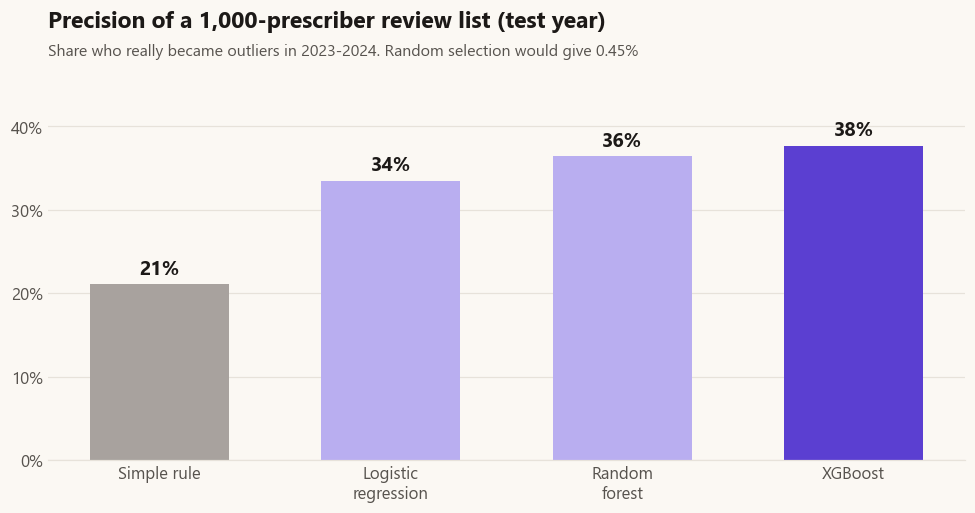

,pr_auc,roc_auc,precision_top_1000,lift_top_1000,recall_top_1pct
model,,,,,
Rule: closeness to peer 99th pct,0.1489,0.9213,0.211,47.3,0.4354
Logistic regression,0.1587,0.9414,0.335,75.0,0.3942
Random forest,0.2194,0.9502,0.364,81.5,0.4998
XGBoost,0.2330,0.9486,0.377,84.4,0.5211


In [2]:
res = pd.DataFrame(metrics["results"]["test"]).set_index("model")
order = ["Rule: closeness to peer 99th pct", "Logistic regression", "Random forest", "XGBoost"]
labels = ["Simple rule", "Logistic\nregression", "Random\nforest", "XGBoost"]
vals = res.loc[order, "precision_top_1000"]

fig, ax = plt.subplots(figsize=(9, 4.8))
bars = ax.bar(labels, vals, color=[vs.GREY, vs.VIOLET_LIGHT, vs.VIOLET_LIGHT, vs.VIOLET], width=0.6)
ax.bar_label(bars, labels=[f"{v:.0%}" for v in vals], padding=4, fontsize=13, fontweight="bold", color=vs.INK)
ax.set_ylim(0, vals.max() * 1.25)
vs.pct(ax)
ax.set_title("Precision of a 1,000-prescriber review list (test year)")
vs.subtitle(ax, f"Share who really became outliers in 2023-2024. Random selection would give {res['base_rate'].iloc[0]:.2%}")
vs.save(fig, "01_model_comparison")
plt.show()
res[["pr_auc", "roc_auc", "precision_top_1000", "lift_top_1000", "recall_top_1pct"]]

## 2. How many future outliers are caught as the review list grows

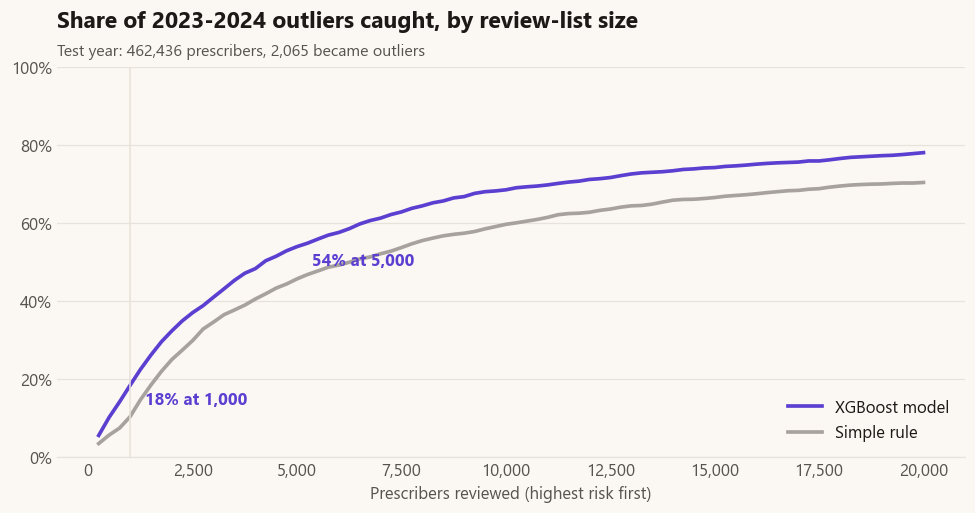

In [3]:
def capture_curve(y, s, sizes):
    order = np.argsort(-s)
    cum = np.cumsum(y[order])
    return [cum[k - 1] / y.sum() for k in sizes]

y = scores["label"].to_numpy()
sizes = np.linspace(250, 20000, 80).astype(int)
fig, ax = plt.subplots()
for col, name, colour in [("model_score", "XGBoost model", vs.VIOLET), ("rule_score", "Simple rule", vs.GREY)]:
    ax.plot(sizes, capture_curve(y, scores[col].to_numpy(), sizes), color=colour, label=name)
for k in (1000, 5000):
    m = capture_curve(y, scores["model_score"].to_numpy(), [k])[0]
    ax.annotate(f"{m:.0%} at {k:,}", (k, m), textcoords="offset points", xytext=(10, -4), ha="left", va="top",
                fontweight="bold", color=vs.VIOLET)
ax.axvline(1000, color=vs.GRID, linewidth=1)
vs.pct(ax)
ax.set_ylim(0, 1)
ax.set_xlabel("Prescribers reviewed (highest risk first)")
ax.set_title("Share of 2023-2024 outliers caught, by review-list size")
vs.subtitle(ax, f"Test year: {len(y):,} prescribers, {int(y.sum()):,} became outliers")
ax.legend(loc="lower right")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
vs.save(fig, "02_capture_curve")
plt.show()

## 3. Calibration: a predicted risk of 5% really means about 5%

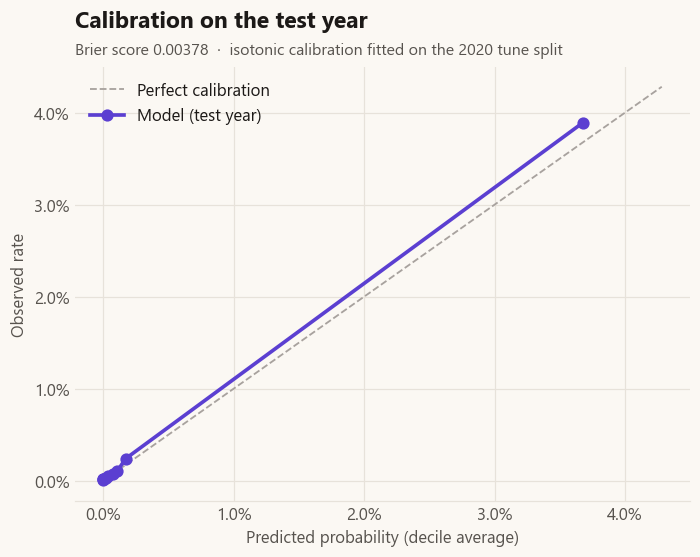

,predicted,observed
model_probability,,
0,0.000000,0.000065
1,0.000000,0.000238
2,0.000000,0.000173
3,0.000068,0.000216
4,0.000191,0.000346
5,0.000402,0.000519
6,0.000786,0.000757
7,0.001077,0.001016
8,0.001725,0.002400


In [4]:
bins = pd.qcut(scores["model_probability"].rank(method="first"), 10, labels=False)
cal = scores.groupby(bins).agg(predicted=("model_probability", "mean"), observed=("label", "mean"))
top = cal.max().max() * 1.1

fig, ax = plt.subplots(figsize=(6.5, 5.2))
ax.plot([0, top], [0, top], color=vs.GREY, linestyle="--", linewidth=1.2, label="Perfect calibration")
ax.plot(cal["predicted"], cal["observed"], color=vs.VIOLET, marker="o", markersize=7, label="Model (test year)")
vs.pct(ax, "x", 1); vs.pct(ax, "y", 1)
ax.set_xlabel("Predicted probability (decile average)")
ax.set_ylabel("Observed rate")
ax.grid(axis="x", visible=True)
ax.set_title("Calibration on the test year")
vs.subtitle(ax, f"Brier score {metrics['calibration']['brier_test']}  ·  isotonic calibration fitted on the 2020 tune split")
ax.legend(loc="upper left")
vs.save(fig, "03_calibration")
plt.show()
cal

## 4. What drives the risk score (SHAP)

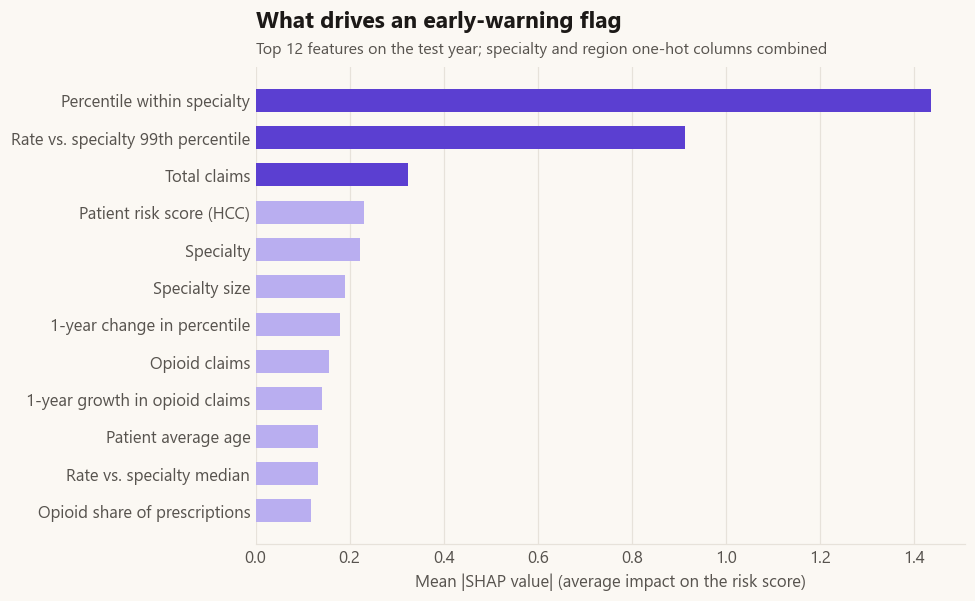

In [5]:
prep, booster = art["prep"], art["booster"]
rng = np.random.default_rng(42)
pos = np.flatnonzero(test["label"].to_numpy() == 1)
neg = rng.choice(np.flatnonzero(test["label"].to_numpy() == 0), 15000, replace=False)
sample = test.iloc[np.concatenate([pos, neg])]
Xs = pd.DataFrame(prep.transform(sample[art["categorical"] + art["numeric"]]), columns=art["features"])
explainer = shap.TreeExplainer(booster)
sv = explainer.shap_values(Xs)

NICE = {"rate_vs_peer_p99": "Rate vs. specialty 99th percentile", "peer_percentile": "Percentile within specialty",
        "rate_vs_peer_median": "Rate vs. specialty median", "opioid_rate": "Opioid share of prescriptions",
        "was_outlier_prev_year": "Was an outlier last year", "percentile_change_1y": "1-year change in percentile",
        "rate_change_1y": "1-year change in opioid rate", "opioid_claims": "Opioid claims",
        "total_claims": "Total claims", "long_acting_share": "Long-acting opioid share",
        "days_per_opioid_claim": "Days supplied per opioid claim", "opioid_patient_share": "Share of patients on opioids",
        "bene_avg_risk_score": "Patient risk score (HCC)", "bene_avg_age": "Patient average age",
        "opioid_claims_growth_1y": "1-year growth in opioid claims", "peer_count": "Specialty size",
        "total_beneficiaries": "Patients", "present_prev_year": "Present last year", "rural": "Rural practice"}
imp = (pd.Series(np.abs(sv).mean(axis=0), index=Xs.columns)
       .groupby(lambda c: c.split("_", 1)[0] + " group" if c.startswith(("specialty_group", "census_region")) else c)
       .sum().sort_values().tail(12))
imp.index = [NICE.get(i, i.replace("specialty group", "Specialty").replace("census group", "Region")) for i in imp.index]

fig, ax = plt.subplots(figsize=(9, 5.6))
bars = ax.barh(imp.index, imp.values, color=[vs.VIOLET if v >= imp.values[-3] else vs.VIOLET_LIGHT for v in imp.values],
               height=0.62)
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
ax.set_xlabel("Mean |SHAP value| (average impact on the risk score)")
ax.set_title("What drives an early-warning flag")
vs.subtitle(ax, "Top 12 features on the test year; specialty and region one-hot columns combined")
vs.save(fig, "04_feature_importance")
plt.show()

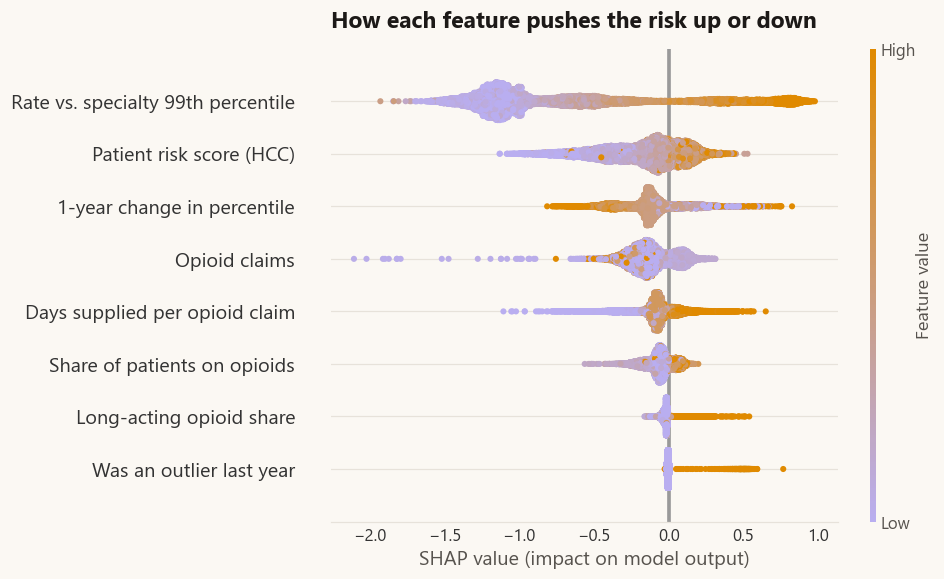

In [6]:
top_features = ["rate_vs_peer_p99", "percentile_change_1y", "opioid_patient_share", "long_acting_share",
                "was_outlier_prev_year", "days_per_opioid_claim", "opioid_claims", "bene_avg_risk_score"]
idx = [list(Xs.columns).index(f) for f in top_features]
plt.figure()
shap.summary_plot(sv[:, idx], Xs.iloc[:, idx], feature_names=[NICE[f] for f in top_features], show=False,
                  cmap=plt.matplotlib.colors.LinearSegmentedColormap.from_list("v", [vs.VIOLET_LIGHT, vs.AMBER]))
fig = plt.gcf(); fig.set_size_inches(9, 5.4); fig.patch.set_facecolor(vs.PAPER)
plt.gca().set_facecolor(vs.PAPER)
plt.title("How each feature pushes the risk up or down", loc="left", fontsize=15, fontweight="bold", pad=14)
vs.save(fig, "05_shap_summary")
plt.show()

## 5. Where the flags land: review-list composition by specialty

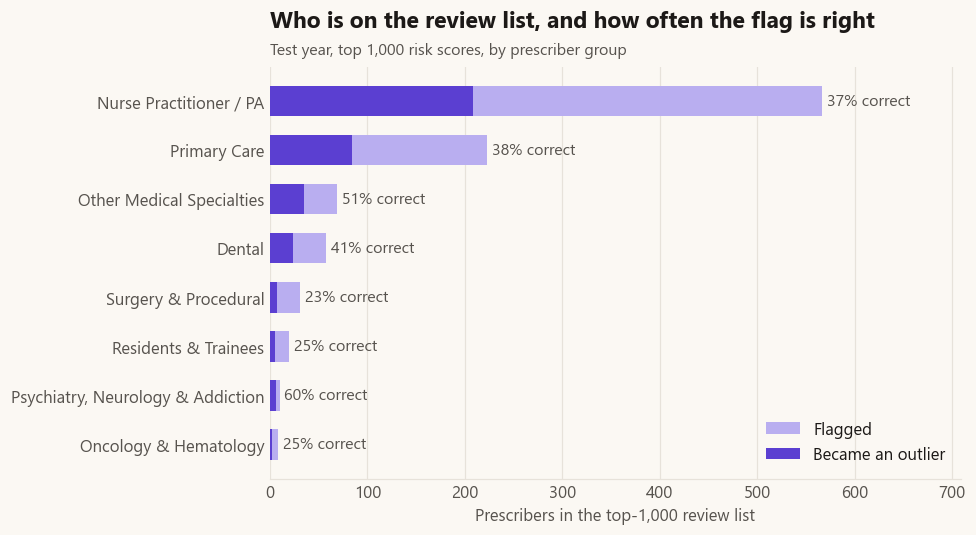

,flagged,became_outlier,precision
specialty_group,,,
Nurse Practitioner / PA,567,208,0.366843
Primary Care,223,84,0.376682
Other Medical Specialties,69,35,0.507246
Dental,58,24,0.413793
Surgery & Procedural,31,7,0.225806
Residents & Trainees,20,5,0.250000
"Psychiatry, Neurology & Addiction",10,6,0.600000
Oncology & Hematology,8,2,0.250000


In [7]:
scores["flagged"] = scores["model_score"].rank(ascending=False) <= 1000
comp = (scores[scores.flagged].groupby("specialty_group")
        .agg(flagged=("label", "size"), became_outlier=("label", "sum"))
        .assign(precision=lambda d: d.became_outlier / d.flagged)
        .sort_values("flagged", ascending=True).tail(8))

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(comp.index, comp["flagged"], color=vs.VIOLET_LIGHT, height=0.62, label="Flagged")
ax.barh(comp.index, comp["became_outlier"], color=vs.VIOLET, height=0.62, label="Became an outlier")
for i, (f, b, p) in enumerate(comp[["flagged", "became_outlier", "precision"]].itertuples(index=False)):
    ax.text(f + 5, i, f"{p:.0%} correct", va="center", fontsize=10.5, color=vs.INK_2)
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
ax.set_xlabel("Prescribers in the top-1,000 review list")
ax.set_title("Who is on the review list, and how often the flag is right")
vs.subtitle(ax, "Test year, top 1,000 risk scores, by prescriber group")
ax.legend(loc="lower right")
ax.set_xlim(0, comp["flagged"].max() * 1.25)
vs.save(fig, "06_review_list_by_specialty")
plt.show()
comp.sort_values("flagged", ascending=False)

## 6. Conclusions

| | Finding |
|---|---|
| 1 | On the untouched 2022 test year, a 1,000-prescriber review list built from the XGBoost score is **37.7% correct (95% CI 34.3-40.4%)**, versus **21.1% for the simple rule** and 0.45% for random selection (**84x lift**). The gain over the rule is +16.6 points (95% CI +12.8 to +19.7). |
| 2 | The model catches **52% of all future outliers in the top 1% of scores** (44% for the rule), and the 2021 backtest shows the same pattern (38.4% vs 21.8% precision). |
| 3 | Probabilities are **close to calibrated** (mean predicted 0.41% vs 0.45% observed, Brier 0.0038), slightly conservative on the test year. |
| 4 | The strongest signals are **where a prescriber already sits within their specialty** (percentile and closeness to the 99th percentile), then **prescribing volume**, **patient risk scores**, **specialty** and **how fast their percentile is rising**. |

**Limitations:** Medicare Part D only; the label is statistical (an outlier is a reason to review, not proof of harm);
prescribers must appear in both follow-up years, so people who stop billing Medicare are not scored; performance
should be re-checked every year as prescribing patterns change.